# Sensitivity (impact) analysis for ReMo3D

This notebook produces 2D contour plots of the Fréchet sensitivity kernel in the (r, z) cross-section. Each plot answers the question **"how much does each area of the formation contribute to this measurement?"**

Two methods are exposed by `remo3d.sensitivity`:

* **Born / analytical** — closed-form kernel using full-space Green's functions in a *homogeneous* background ρ₀. Fast, runs in a fraction of a second. The kernel shape is exact for a homogeneous medium and a good approximation for mildly heterogeneous formations.
* **Perturbation / finite-difference** — perturb ρ in each cell, re-run `Model.compute_synthetic_logs`, take ΔRₐ / Δ(lnρ). Honours the actual layered + invaded model but costs **one FEM solve per cell** (very slow).

Convention: the kernel is the integrand of
$$\int\!\!\int S(r,z)\,dr\,dz \;\approx\; R_a^{\text{homog}} \;=\; \rho_0,$$
so each plotted value represents the contribution per unit cross-section area (the axisymmetric Jacobian $2\pi r$ is already included).

In [1]:
# --- Choose which remo3d to import: local source folder vs. installed kernel copy ---
# "folder" = this repo's live source (v1.4.0, includes remo3d.sensitivity)
# "kernel" = the copy installed in the ReMo3D env (v1.1.0 — has NO sensitivity module,
#            so THIS notebook requires "folder"). The toggle is kept for consistency
#            with other notebooks / quick A-B comparisons of the two code versions.
import sys

REPO_ROOT = "/mnt/g/usr_data/kaveh/projects/ReMo3D"
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from remo3d_loader import load_remo3d

REMO3D_SOURCE = "folder"          # <-- set to "kernel" to load the installed copy instead
remo3d = load_remo3d(REMO3D_SOURCE)

[remo3d_loader] source='folder'  version=1.4.0
[remo3d_loader] loaded from: /mnt/g/usr_data/kaveh/projects/ReMo3D/remo3d/__init__.py


In [8]:
import numpy as np
import matplotlib.pyplot as plt

import importlib
import remo3d.sensitivity as sensitivity

importlib.reload(sensitivity)   # picks up live edits to sensitivity.py when REMO3D_SOURCE == "folder"

from remo3d.sensitivity import (
    plot_sensitivity,
    plot_sensitivity_doi,
    analytical_sensitivity,
    perturbation_sensitivity,
    _selftest,
)

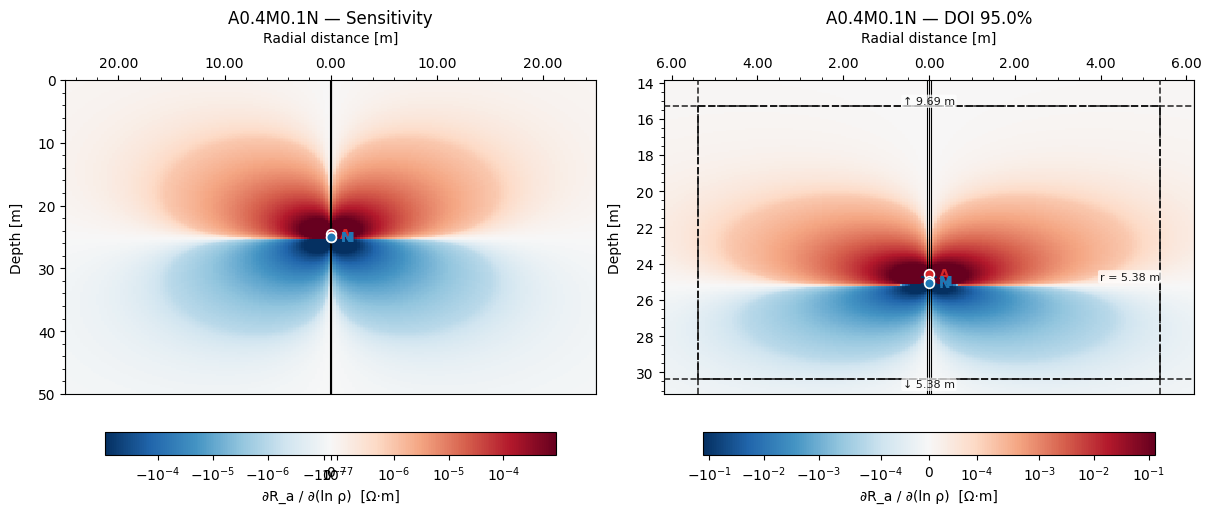

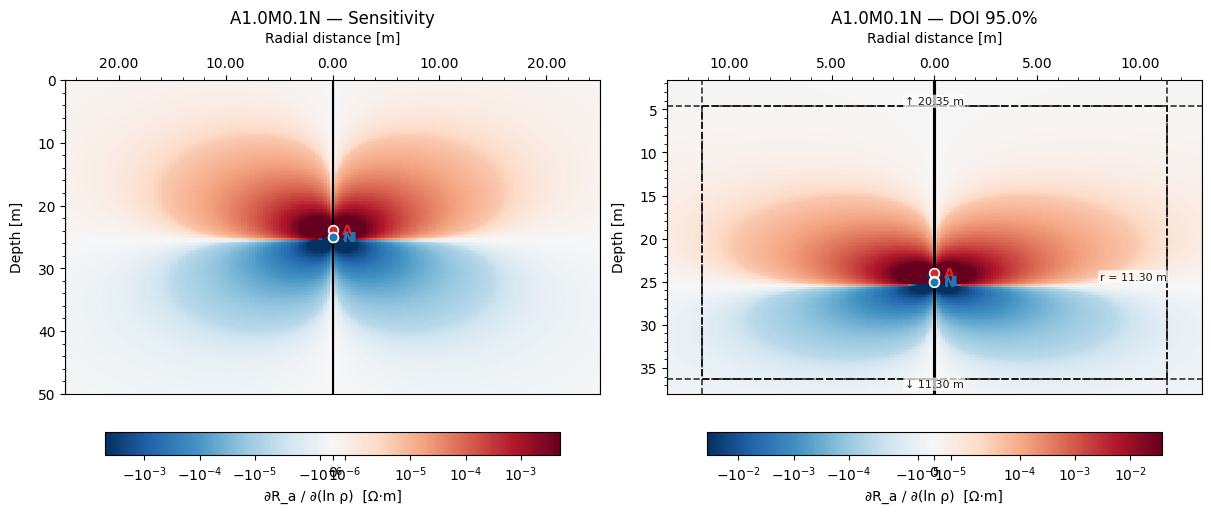

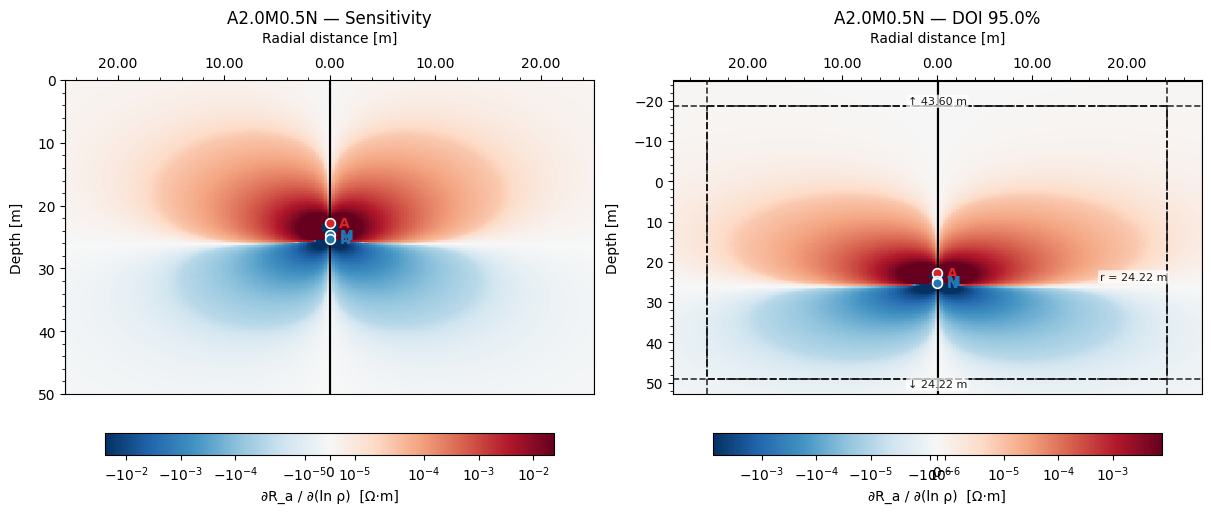

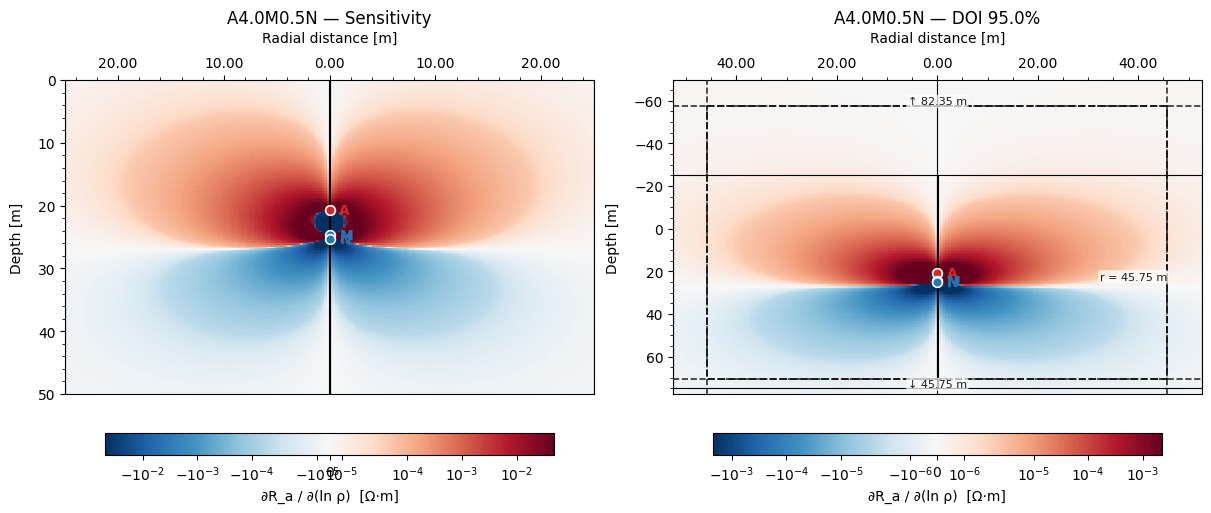

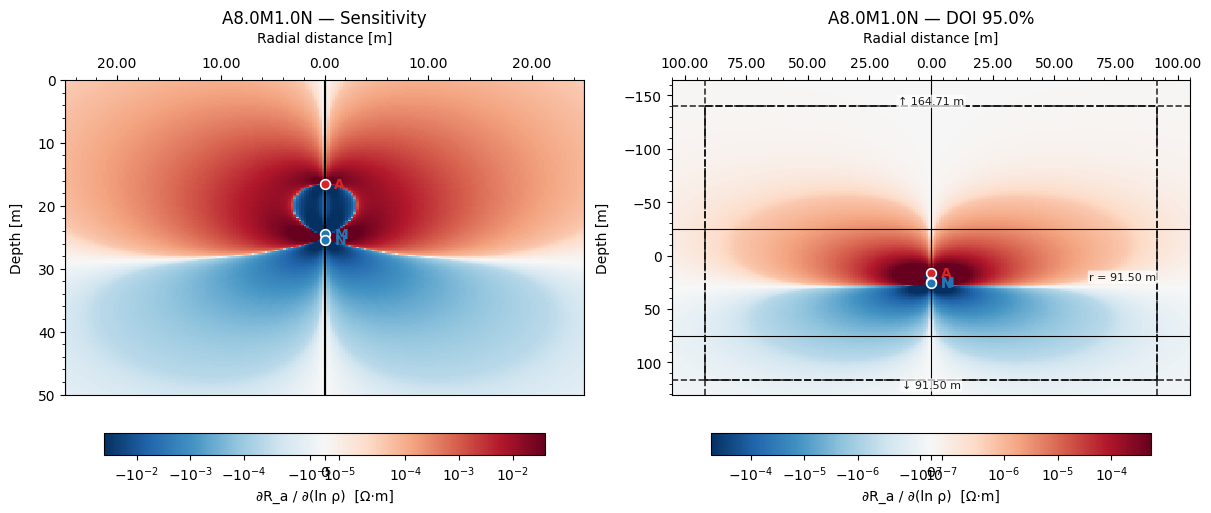

In [12]:
tools = ["A0.4M0.1N", "A1.0M0.1N", "A2.0M0.5N", "A4.0M0.5N", "A8.0M1.0N"]

depth = 25.0
rho = 1.0

formation_homo = np.array([
    [depth - 50.0, depth + 50.0, np.nan, np.nan, rho]
])

borehole_homo = np.array([
    [depth - 50.0, 0.1, rho],
    [depth + 50.0, 0.1, rho],
])



fraction = 0.95
for i, tool in enumerate(tools):

    fig, axes = plt.subplots(1, 2,
    figsize=(12, 5),
    constrained_layout=True)
    
    plot_sensitivity(
        tool=tool,
        depth=depth,
        formation_model=formation_homo,
        borehole_model=borehole_homo,
        method="born",
        r_lim=(-25, 25),
        z_lim=(depth - 25, depth + 25),
        n_r=200,
        n_z=200,
        rho_background=rho,
        ax=axes[0],
    )
    axes[0].set_title(f"{tool} — Sensitivity")

    plot_sensitivity_doi(
        tool=tool,
        depth=depth,
        formation_model=formation_homo,
        borehole_model=borehole_homo,
        fraction=fraction,
        n_r=200,
        n_z=200,
        rho_background=rho,
        ax=axes[1],
    )
    axes[1].set_title(f"{tool} — DOI {fraction*100}%")
    plt.show()

